In [46]:
import numpy as np
import pandas as pd

In [47]:
df=pd.read_csv(r"C:\Users\Suyash\Downloads\credit_risk_dataset.csv.zip")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [48]:
X=df[['loan_amnt','person_income','loan_percent_income','cb_person_cred_hist_length']]
y=df['loan_status']
print(X.head())
print(y.head())

   loan_amnt  person_income  loan_percent_income  cb_person_cred_hist_length
0      35000          59000                 0.59                           3
1       1000           9600                 0.10                           2
2       5500           9600                 0.57                           3
3      35000          65500                 0.53                           2
4      35000          54400                 0.55                           4
0    1
1    0
2    1
3    1
4    1
Name: loan_status, dtype: int64


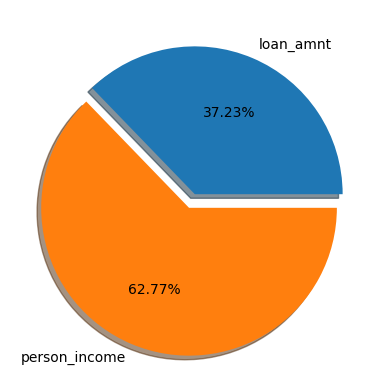

In [49]:
import matplotlib.pyplot as plt

row = X.iloc[0]


values = [row['loan_amnt'], row['person_income']]


labels = ['loan_amnt','person_income']

plt.pie(values, labels=labels, autopct='%1.2f%%', shadow=True, explode=[0.0, 0.1])
plt.show()


In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df['Cluster']=clusters
print(df.groupby('Cluster')[['person_income',
                  'loan_amnt','loan_status',
                  'loan_percent_income','cb_person_cred_hist_length']].mean(numeric_only=True))
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

         person_income     loan_amnt  loan_status  loan_percent_income  \
Cluster                                                                  
0         59295.225061   6220.534810     0.158776             0.119632   
1         64814.660222  16543.699879     0.378886             0.292575   
2         84813.916854   8581.576193     0.148497             0.130604   

         cb_person_cred_hist_length  
Cluster                              
0                          3.865225  
1                          4.977590  
2                         11.798265  


In [130]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=300,random_state=42,learning_rate=0.03,max_depth=6)
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
print(xgb_pred.shape)
print(df['loan_status'].value_counts())
scale_pos_weight = 25473 / 7108

print("The imbalance database",scale_pos_weight)

(26065,)
loan_status
0    25473
1     7108
Name: count, dtype: int64
The imbalance database 3.5837084974676423


In [131]:
importance = xgb.feature_importances_

print(importance)

[0.09852836 0.21841733 0.6120548  0.07099956]


In [132]:
feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})
feature_importance=feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)
     
    

                      Feature  Importance
2         loan_percent_income    0.612055
1               person_income    0.218417
0                   loan_amnt    0.098528
3  cb_person_cred_hist_length    0.071000


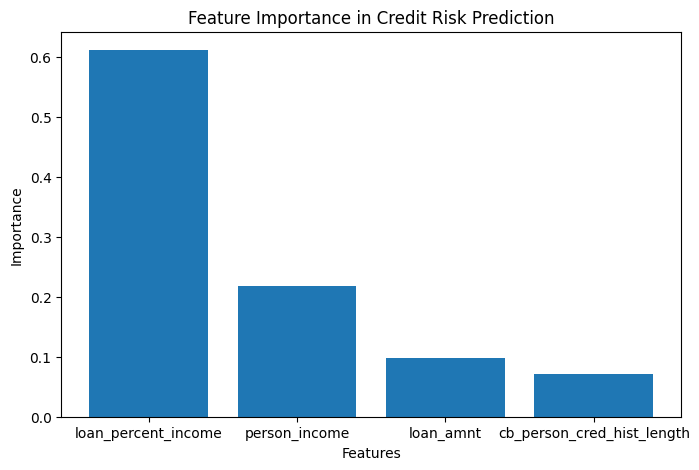

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance in Credit Risk Prediction")

plt.show()

In [134]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,xgb_pred)
accuracy

0.841856896220986

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test,
                            xgb_pred
                           ))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91     20401
           1       0.75      0.43      0.55      5664

    accuracy                           0.84     26065
   macro avg       0.80      0.69      0.73     26065
weighted avg       0.83      0.84      0.83     26065



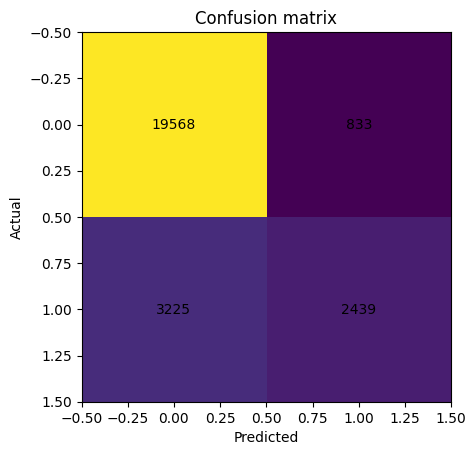

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm=confusion_matrix(
     y_test,
     xgb_pred
 )
plt.imshow(cm);
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j,i,cm[i,j],ha='center',va='center')





In [61]:

risk_category=[]
for p in xgb_pred:
    if p<0.3:
        risk_category.append("Low Risk")

    elif p < 0.7:
        risk_category.append("Medium Risk")

    else:
        risk_category.append("High Risk")
        

In [62]:
for r in risk_category:
    print(r)

Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
High Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
High Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
Low Risk
High Risk
Low Risk
Low Risk
Low

In [63]:
def recommend(row):

    recommendations = []

    if row['loan_amnt']>0.6*row['person_income']:
        recommendations.append( 
            "The loan is not correct for your income"
        )

    if row['loan_status']<1:
        recommendations.append(
            "The loan is not fully paid"
        )
    if row['cb_person_cred_hist_length'] < 2:
        recommendations.append(
        "Build a longer credit history."
        )    
        
    return " |".join(recommendations)

In [64]:
df['Recommendation']=df.apply(
    recommend,
    axis=1
)
print(df['Recommendation'])

0                                               
1                     The loan is not fully paid
2                                               
3                                               
4        The loan is not correct for your income
                          ...                   
32576                 The loan is not fully paid
32577                 The loan is not fully paid
32578                                           
32579                 The loan is not fully paid
32580                 The loan is not fully paid
Name: Recommendation, Length: 32581, dtype: str
